<div align="center">
  <img src="fotos/logo_utem.png" alt="Logo UTEM" width="120" style="max-height:140px; height:auto;"/>
  <br><br>

  <p style="margin:2px 0; font-size:16px; font-weight:400; text-shadow:none;">UNIVERSIDAD TECNOLOGICA METROPOLITANA</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INGENIERIA CIVIL EN CIENCIA DE DATOS</p>
  <p style="margin:2px 0; font-size:14px; font-weight:400; text-shadow:none;">INFB8090 - COMPUTACION PARALELA Y DISTRIBUIDA</p>

  <br><br>
  <h2 style="margin:0;">LABORATORIO N 1</h2>
  <br>
  <h1 style="margin:0;"><i>Diagnostico experimental de paralelismo</i></h1>

  <br><br>
  <p style="margin:2px 0;">Profesor: Michael Miranda Sandoval</p>
  <p style="margin:2px 0;">Integrante: Diego Silva Madariaga</p>
  <p style="margin:2px 0;">Fecha: 09 de abril de 2026</p>
</div>

## Contexto y objetivo del laboratorio

El procesamiento de grandes volumenes de datos exige alta capacidad computacional. Por lo que antes de pasar a paralelismo como tal es necesario saber diagnosticar el rendimiento del codigo midiendo sus tiempos de ejecucion. El objetivo de este primer laboratorio es desarrollar un diagnostico experimental en Python utilizando cargas de trabajo simuladas,esto permitira diferenciar de forma practica las tareas estrictamente secuenciales de aquellas que poseen unidades de trabajo independientes, estableciendo un criterio claro para decidir cuando la computacion paralela aporta valor real en la ciencia de datos.

In [6]:
import time
import random
import matplotlib.pyplot as plt
import math
import concurrent.futures

### Ejercicio 1: Medicion base de una tarea secuencial simple (Calculo de Inercia)

 El codigo simula el calculo de inercia espacial (Suma de Errores al Cuadrado), es cual es una operacion matematica que se usa para evaluar la cohesion de grupos en modelos de segmentacion no supervisada. para esto, se genera un "centroide" en 3D y conjuntos de datos sinteticos de 100,000, 500,000 y 1,000,000 de registros.

Para establecer la linea base secuencial, la funcion recorre la lista completa y calcula la distancia de cada registro hacia el centroide, elemento por elemento. Esto permite medir de forma directa como escala el tiempo de ejecucion al procesar distintos volumenes de datos sin ningun tipo de optimizacion.

n=100000 | inercia=398336973.06 | tiempo=0.022859 s
n=500000 | inercia=1672089481.76 | tiempo=0.115673 s
n=1000000 | inercia=3120316448.06 | tiempo=0.225484 s


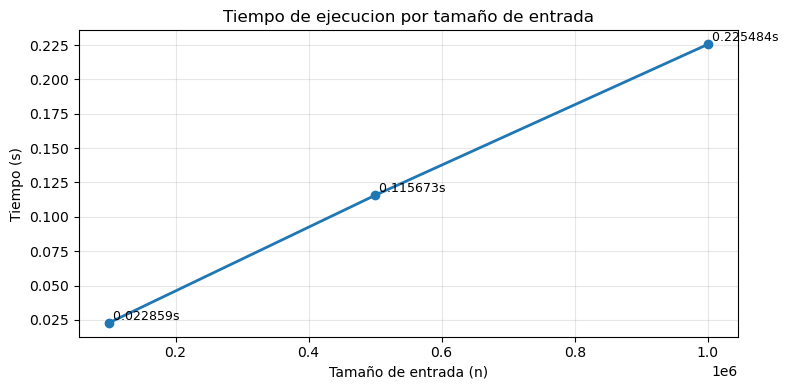

In [7]:
SEED_EJ1 = 42

def generar_datos_ej1(n, rng):
    centroide = (rng.uniform(20, 60), rng.uniform(10, 100), rng.uniform(1, 100))
    clientes = [(rng.uniform(20, 60), rng.uniform(10, 100), rng.uniform(1, 100)) for _ in range(n)]
    return centroide, clientes

def calcular_inercia_secuencial(centroide, clientes):
    # O(n)
    inercia = 0.0
    cx, cy, cz = centroide
    for px, py, pz in clientes:
        dist_cuadrada = (px - cx)**2 + (py - cy)**2 + (pz - cz)**2
        inercia += dist_cuadrada
    return inercia

def graficar_tiempos(resultados):
    tamanos = [n for n, _, _ in resultados]
    tiempos = [t for _, _, t in resultados]

    plt.figure(figsize=(8, 4))
    plt.plot(tamanos, tiempos, marker="o", linewidth=2)
    plt.title("Tiempo de ejecucion por tamaño de entrada")
    plt.xlabel("Tamaño de entrada (n)")
    plt.ylabel("Tiempo (s)")
    plt.grid(True, alpha=0.3)

    for n, t in zip(tamanos, tiempos):
        plt.text(n, t, f" {t:.6f}s", fontsize=9, va="bottom")

    plt.tight_layout()
    plt.show()

rng = random.Random(SEED_EJ1)
tamanos = [100_000, 500_000, 1_000_000]
resultados = []

for n in tamanos:
    centroide, clientes = generar_datos_ej1(n, rng)

    inicio = time.perf_counter()
    inercia_total = calcular_inercia_secuencial(centroide, clientes)
    fin = time.perf_counter()

    duracion = fin - inicio
    resultados.append((n, inercia_total, duracion))
    print(f"n={n} | inercia={inercia_total:.2f} | tiempo={duracion:.6f} s")

graficar_tiempos(resultados)

El tiempo de ejecucion medido demuestra un crecimiento proporcional al tamano de la entrada, confirmando un comportamiento lineal de complejidad O(n). Al multiplicar el volumen de datos el tiempo de procesamiento se incrementa en una proporcion casi identica, escalando de 0.023 s a 0.112 s.Esto evidencia la naturaleza secuencial de la implementacion, la cual es producto directo del uso del ciclo iterativo. 

Aunque el calculo de la inercia es una operacion matematicamente independiente, el codigo obliga al procesador a calcular y acumular cada distancia de forma individual antes de avanzar al siguiente registro, esto establece una linea base clara, el cuello de botella actual no radica en dependencias complejas entre los datos, sino en la restriccion del diseno algoritmico, haciendo de este calculo un excelente candidato para futuras optimizaciones mediante paralelismo de datos.

### Ejercicio 2: Comparacion de variantes de procesamiento y discusion sobre paralelizacion 

Se evaluan dos enfoques distintos para procesar una misma coleccion de datos, para esto se simula el calculo de un puntaje de segmentacion aplicando una transformacion matematica costosa sobre una lista de 400,000 registros generados aleatoriamente.

El codigo contrasta dos metodos de ejecucion. La primera es un procesamiento iterativo tradicional que evalua la carga matematica elemento por elemento de principio a fin. La segunda es un procesamiento por bloques, el cual divide la lista original en subconjuntos de 50,000 registros y los procesa de forma agrupada. 

Esta comparacion no busca paralelizar aun, sino dejar en evidencia la estructura del problema para observar si el agrupamiento en bloques revela subconjuntos de datos independientes que faciliten una futura distribucion de tareas.

Total secuencial: 10810027.3063 | Tiempo: 0.075967 s
Total por bloques: 10810027.3063 | Tiempo: 0.076957 s


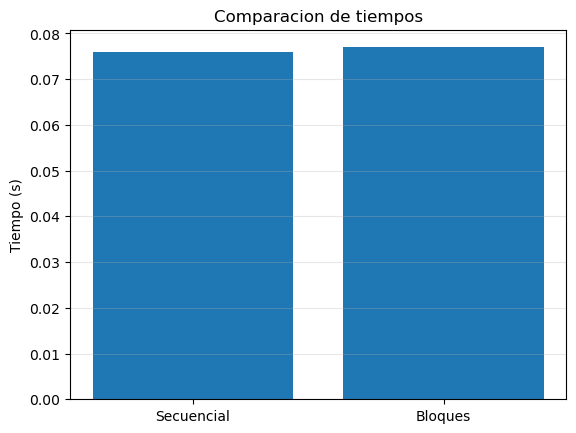

In [8]:
SEED_EJ2 = 43

def generar_datos_ej2(n, rng):
    return [rng.uniform(1, 1000) for _ in range(n)]

def carga_elemental(x):
    return math.sqrt(x) + math.log(x + 1)

def procesar_secuencial(datos):
    # O(n)
    total = 0.0
    for x in datos:
        total += carga_elemental(x)
    return total

def procesar_por_bloques(datos, tam_bloque=50_000):
    # O(n), bloques independientes
    total = 0.0
    for inicio_idx in range(0, len(datos), tam_bloque):
        bloque = datos[inicio_idx : inicio_idx + tam_bloque]
        subtotal = 0.0
        for x in bloque:
            subtotal += carga_elemental(x)
        total += subtotal
    return total

def graficar_comparacion_tiempos(tiempo_sec, tiempo_bloq):
    etiquetas = ["Secuencial", "Bloques"]
    tiempos = [tiempo_sec, tiempo_bloq]
    plt.bar(etiquetas, tiempos)
    plt.title("Comparacion de tiempos")
    plt.ylabel("Tiempo (s)")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

rng = random.Random(SEED_EJ2)
datos = generar_datos_ej2(400_000, rng)

inicio_sec = time.perf_counter()
total_sec = procesar_secuencial(datos)
fin_sec = time.perf_counter()

inicio_bloq = time.perf_counter()
total_bloq = procesar_por_bloques(datos, 50_000)
fin_bloq = time.perf_counter()

tiempo_sec = fin_sec - inicio_sec
tiempo_bloq = fin_bloq - inicio_bloq

print(f"Total secuencial: {total_sec:.4f} | Tiempo: {tiempo_sec:.6f} s")
print(f"Total por bloques: {total_bloq:.4f} | Tiempo: {tiempo_bloq:.6f} s")
graficar_comparacion_tiempos(tiempo_sec, tiempo_bloq)

Se observa que los dos codigos dan el mismo total, lo que comprueba que separar los datos en bloques no altera el calculo final. Revisando los tiempos la ejecucion de bloques se demoro un poco mas. Esto por el procesador gasta tiempo extra haciendo los cortes de la lista y manejando los ciclos. 

Lo valioso de este ejercicio es notar que los bloques son subconjuntos totalmente independientes entre si, para procesar la informacion de un bloque no necesitas saber absolutamente nada de lo que hay en los otros. Al ver esta independencia, queda claro que si hay una oportunidad real para paralelizar el codigo. Esta opcion tendria todo el sentido del mundo si corrieramos el programa en multiples nucleos, ya que podriamos mandarle un bloque diferente a cada nucleo para que trabajen en simultaneo, en lugar de hacer que un solo nucleo se coma toda la lista uno por uno.

## Ejercicio 3: Caso aplicado a ciencia de datos y decision diagnostica

El problema consiste en procesar ocho lotes de datos donde cada lote representa un segmento distinto compuesto por cientos de miles de registros. En este contexto la unidad de trabajo independiente se define como el calculo de las estadisticas descriptivas (media, valor maximo y valor minimo) para un lote en especifico. 

El objetivo de esta medicion es registrar el tiempo total que toma el procesamiento secuencial de todos los segmentos para luego analizar la estructura del problema. Con esto se tomara una decision diagnostica fundamentada sobre si las caracteristicas de estas unidades de trabajo ameritan mantener una ejecucion puramente secuencial, implementar computacion paralela en un mismo equipo o escalar hacia un entorno de computacion distribuida

Lote 1: media=502.49, min=0.00, max=1000.00
Lote 2: media=501.30, min=0.03, max=999.99
Lote 3: media=499.68, min=0.01, max=999.98
Lote 4: media=499.73, min=0.00, max=999.99
Lote 5: media=500.69, min=0.01, max=1000.00
Lote 6: media=501.13, min=0.00, max=1000.00
Lote 7: media=501.40, min=0.01, max=999.99
Lote 8: media=500.04, min=0.01, max=999.99

Tiempo total de procesamiento: 0.037844 s


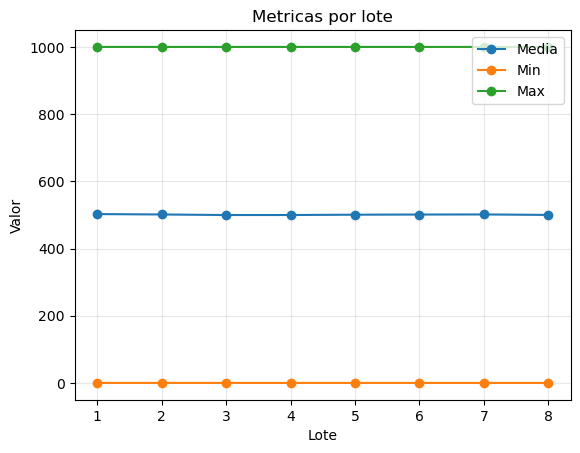

In [9]:
SEED_EJ3 = 44

def generar_lotes_ej3(num_lotes, tam_lote, rng):
    return [[rng.uniform(0, 1000) for _ in range(tam_lote)] for _ in range(num_lotes)]

def evaluar_lote(lote):
    suma = 0.0
    val_min = float('inf')
    val_max = float('-inf')
    
    for x in lote:
        suma += x
        if x < val_min: 
            val_min = x
        if x > val_max: 
            val_max = x
            
    media = suma / len(lote)
    return media, val_min, val_max

def graficar_metricas_lotes(resumenes):
    lotes_idx = [r[0] for r in resumenes]
    medias = [r[1] for r in resumenes]
    minimos = [r[2] for r in resumenes]
    maximos = [r[3] for r in resumenes]
    plt.plot(lotes_idx, medias, marker="o", label="Media")
    plt.plot(lotes_idx, minimos, marker="o", label="Min")
    plt.plot(lotes_idx, maximos, marker="o", label="Max")
    plt.title("Metricas por lote")
    plt.xlabel("Lote")
    plt.ylabel("Valor")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

rng = random.Random(SEED_EJ3)
lotes = generar_lotes_ej3(8, 120_000, rng)
resumenes = []

inicio_total = time.perf_counter()

for i, lote in enumerate(lotes, start=1):
    media, val_min, val_max = evaluar_lote(lote)
    resumenes.append((i, media, val_min, val_max))

fin_total = time.perf_counter()

for res in resumenes:
    print(f"Lote {res[0]}: media={res[1]:.2f}, min={res[2]:.2f}, max={res[3]:.2f}")

print(f"\nTiempo total de procesamiento: {fin_total - inicio_total:.6f} s")
graficar_metricas_lotes(resumenes)

Cada lote representa a un segmento distinto y el calculo de sus estadisticas es una unidad de trabajo completamente independiente, ya que el valor maximo o la media del lote 1 no afecta en nada a los calculos del lote 2. 

Pensando en un escenario real de ciencia de datos como la evaluacion de multiples perfiles tras ejecutar un algoritmo de agrupamiento, la estrategia computacional seria aplicar paralelismo en un mismo equipo (multiprocesamiento local). Esta decision se justifica al evaluar el volumen de datos y el costo computacional, no es una operacion lo suficientemente pesada como para justificar una arquitectura distribuida en varios computadores, con multiprocesamiento local basta. 

Si mandaramos estos lotes a distintos pc en una red el tiempo gastado en transferir la informacion y coordinar los resultados seria mucho mayor que el tiempo real de calculo. Por lo tanto paralelizar a nivel de procesador en una sola maquina local permite aprovechar la independencia de las particiones para este caso.

Con multiprocesamiento local

Lote 1: media=502.49, min=0.00, max=1000.00
Lote 2: media=501.30, min=0.03, max=999.99
Lote 3: media=499.68, min=0.01, max=999.98
Lote 4: media=499.73, min=0.00, max=999.99
Lote 5: media=500.69, min=0.01, max=1000.00
Lote 6: media=501.13, min=0.00, max=1000.00
Lote 7: media=501.40, min=0.01, max=999.99
Lote 8: media=500.04, min=0.01, max=999.99

Tiempo total de procesamiento (Paralelo): 0.150672 s


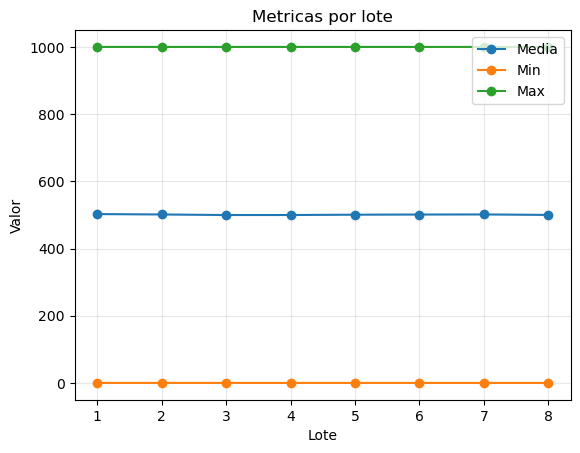

In [10]:
from trabajador import evaluar_lote

SEED_EJ3 = 44

def generar_lotes_ej3(num_lotes, tam_lote, rng):
    return [[rng.uniform(0, 1000) for _ in range(tam_lote)] for _ in range(num_lotes)]

def graficar_metricas_lotes(resumenes):
    lotes_idx = [r[0] for r in resumenes]
    medias = [r[1] for r in resumenes]
    minimos = [r[2] for r in resumenes]
    maximos = [r[3] for r in resumenes]
    plt.plot(lotes_idx, medias, marker="o", label="Media")
    plt.plot(lotes_idx, minimos, marker="o", label="Min")
    plt.plot(lotes_idx, maximos, marker="o", label="Max")
    plt.title("Metricas por lote")
    plt.xlabel("Lote")
    plt.ylabel("Valor")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# Multiproceso con concurrent.futures.ProcessPoolExecutor
if __name__ == '__main__':
    rng = random.Random(SEED_EJ3)
    lotes = generar_lotes_ej3(8, 120_000, rng)
    resumenes = []

    inicio_total = time.perf_counter()

    with concurrent.futures.ProcessPoolExecutor() as executor:
        resultados = list(executor.map(evaluar_lote, lotes))

    for i, (media, val_min, val_max) in enumerate(resultados, start=1):
        resumenes.append((i, media, val_min, val_max))

    fin_total = time.perf_counter()

    for res in resumenes:
        print(f"Lote {res[0]}: media={res[1]:.2f}, min={res[2]:.2f}, max={res[3]:.2f}")

    print(f"\nTiempo total de procesamiento (Paralelo): {fin_total - inicio_total:.6f} s")
    graficar_metricas_lotes(resumenes)

En este caso al ser una tarea muy liviana ni el multiprocesamiento local vale la pena pues el tiempo extra que se gasta en dividir los datos, crear los procesos paralelos y recolectar los resultados finales es mucho mayor que el tiempo que le toma a un solo nucleo realizar los calculos matematicos. A este costo logistico de coordinacion se le conoce como overhead, y en escenarios como este termina haciendo que la ejecucion en paralelo sea mas lenta y menos eficiente que la version secuencial tradicional.

### Conclusiones y reflexion diagnostica final

Para que la aplicacion de paralelismo resulte realmente util, un problema debe poseer una estructura en que exista la independencia de sus tareas o datos, no basta simplemente con que un programa demore mucho tiempo en ejecutarse para concluir que necesita ser paralelizado, pues si el algoritmo es secuencial y cada paso depende de que el calculo anterior haya terminado por completo agregar mas nucleos o procesadores no solucionara la lentitud.Ademas, como se evidencio en los resultados, si la tarea independiente es matematicamente muy liviana, el costo logistico de coordinar los procesos (overhead) hara que el multiprocesamiento sea incluso mas lento que la ejecucion secuencial.

En la ciencia de datos el paralelismo y la distribucion aportan un valor inmenso en tareas repetitivas y de alto volumen, pues como ejemplos de esto son el preprocesamiento masivo de registros o la evaluacion de modelos de aprendizaje no supervisado como algoritmos de segmentacion de clientes. Al trabajar con datasets reales de gran escala y construir proyectos profesionales optimizar estos calculos independientes permite iterar mas rapido y validar clusters de forma eficiente. 

Por lo que este primer laboratorio demuestra por que es absolutamente vital medir antes de intentar optimizar. Establecer una linea base con tiempos de ejecucion permite identificar con evidencia empirica donde esta el verdadero cuello de botella, asegurando que cualquier decision de arquitectura computacional se base en el comportamiento real del codigo y no en simples suposiciones tecnicas.

<div align="center">
  <p style="font-size:11px; color:#8a8a8a; margin:6px 0 0 0;">
    Equipo utilizado: AMD Ryzen 7 5700X | 16 GB RAM | NVIDIA GeForce RTX 4060
  </p>
</div>